# Data Cleaning

In [59]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data set 

In [60]:
df=pd.read_csv("data_set.csv")
df

,customer_id,age,gender,city,income,education,experience_years,monthly_spending,credit_score,signup_date,has_credit_card,loan_amount,employment_type,defaulted
0,C100000,18.0,Male,Faisalabad,97203.41,Bachelor,33,34323.67,728.0,2020-01-01,Yes,162409.81,Unemployed,0
1,C100001,56.0,Female,Islamabad,132084.64,Matric,20,36955.51,439.0,2020-01-02,Yes,207532.68,Government,0
2,C100002,51.0,Female,Lahore,39789.24,Bachelor,26,30520.91,516.0,2020-01-03,Yes,261934.54,Government,0
3,C100003,21.0,Female,Islamabad,110957.74,Matric,23,34385.96,520.0,2020-01-04,No,NaN,Student,1
4,C100004,69.0,Female,Rawalpindi,127385.88,Master,18,34126.80,715.0,2020-01-05,No,92532.55,Business,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3030,C102051,58.0,Male,Rawalpindi,36529.58,Bachelor,15,41294.78,803.0,2025-08-13,Yes,373470.82,Unemployed,0
3031,C100203,42.0,Male,Lahore,65506.98,Intermediate,34,24988.27,427.0,2020-07-22,Yes,276642.15,Private,0
3032,C102772,48.0,Male,Karachi,155931.04,PhD,8,38071.27,NaN,2027-08-04,No,272737.10,Business,0
3033,C100852,23.0,Female,Karachi,95938.08,Intermediate,32,49512.70,663.0,2022-05-02,Yes,251914.61,Unemployed,0


## Handel the missing values and duplicates

In [61]:
df.isnull().sum()

customer_id           0
age                  90
gender                0
city                 76
income              150
education            60
experience_years      0
monthly_spending    120
credit_score         61
signup_date           0
has_credit_card       0
loan_amount         121
employment_type       0
defaulted             0
dtype: int64

###  Handel the Duplicates 

In [62]:
for col in df.select_dtypes(include="object"):
    print(col)
    print(df[col].value_counts(dropna=False).head(10))

customer_id
customer_id
C100203    2
C100568    2
C100584    2
C100674    2
C100718    2
C100852    2
C100891    2
C100992    2
C101111    2
C101123    2
Name: count, dtype: int64
gender
gender
Male        1540
Female      1455
F             14
 FEMALE       12
M              8
male           6
Name: count, dtype: int64
city
city
Islamabad     610
Karachi       590
Faisalabad    586
Lahore        583
Rawalpindi    570
NaN            76
KARACHI         9
Islamabad       6
lahore          5
Name: count, dtype: int64
income
income
NaN          150
missing       16
65506.98       2
67117.72       2
91480.77       2
65042.9        2
60908.43       2
95938.08       2
58855.55       2
106482.66      2
Name: count, dtype: int64
education
education
Bachelor        611
Master          606
PhD             594
Matric          592
Intermediate    572
NaN              60
Name: count, dtype: int64
credit_score
credit_score
NaN        61
353.0      15
unknown    15
566.0      14
537.0      14
596.0   

C:\Users\Cyber\AppData\Local\Temp\ipykernel_16020\626018582.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):


In [63]:
duplicates = df[df.duplicated(subset="customer_id", keep=False)]
duplicates.sort_values("customer_id")

,customer_id,age,gender,city,income,education,experience_years,monthly_spending,credit_score,signup_date,has_credit_card,loan_amount,employment_type,defaulted
203,C100203,42.0,Male,Lahore,65506.98,Intermediate,34,24988.27,427.0,2020-07-22,Yes,276642.15,Private,0
3031,C100203,42.0,Male,Lahore,65506.98,Intermediate,34,24988.27,427.0,2020-07-22,Yes,276642.15,Private,0
568,C100568,42.0,Male,Faisalabad,67117.72,Bachelor,23,36671.61,770.0,2021-07-22,No,298123.97,Government,0
3002,C100568,42.0,Male,Faisalabad,67117.72,Bachelor,23,36671.61,770.0,2021-07-22,No,298123.97,Government,0
3020,C100584,48.0,Male,Faisalabad,91480.77,Intermediate,12,39156.70,454.0,2021-08-07,Yes,308331.38,Government,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3027,C102783,38.0,Female,Islamabad,NaN,Master,2,35409.32,624.0,2027-08-15,No,271575.97,Student,0
3015,C102803,25.0,Male,Faisalabad,97575.41,Matric,5,23509.69,332.0,invalid_date,Yes,211427.02,Student,0
2803,C102803,25.0,Male,Faisalabad,97575.41,Matric,5,23509.69,332.0,invalid_date,Yes,211427.02,Student,0
3019,C102834,67.0,Male,Rawalpindi,73425.25,PhD,18,29137.80,550.0,2027-10-05,No,NaN,Private,0


In [64]:
df = df.drop_duplicates()

In [65]:
df["gender"].duplicated().sum()

np.int64(2994)

In [66]:
df.value_counts("gender")

gender
Male        1520
Female      1440
F             14
 FEMALE       12
M              8
male           6
Name: count, dtype: int64

In [67]:
df["gender"] = df["gender"].str.strip().str.lower()

df["gender"] = df["gender"].replace({
    "m": "Male",
    "male": "Male",
    "f": "Female",
    "female": "Female"
})
df.value_counts("gender")

gender
Male      1534
Female    1466
Name: count, dtype: int64

In [68]:
df.value_counts("city")

city
Islamabad     606
Karachi       586
Faisalabad    579
Lahore        574
Rawalpindi    560
KARACHI         9
Islamabad       6
lahore          5
Name: count, dtype: int64

In [69]:
df["city"] = df["city"].str.strip().str.lower()

df["city"] = df["city"].replace({
    "KARACHI": "Karachi",
    "Islamabad": "Islamabad",
    "lahore": "Lahore"
})
df.value_counts("city")

city
islamabad     612
karachi       595
faisalabad    579
Lahore        579
rawalpindi    560
Name: count, dtype: int64

In [70]:
df.value_counts("education")

education
Bachelor        605
Master          597
Matric          586
PhD             586
Intermediate    566
Name: count, dtype: int64

In [71]:
df.value_counts("employment_type")

employment_type
Private       633
Government    632
Business      601
Student       571
Unemployed    563
Name: count, dtype: int64

### Check Empty and Special Values

In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       3000 non-null   str    
 1   age               2910 non-null   float64
 2   gender            3000 non-null   str    
 3   city              2925 non-null   str    
 4   income            2851 non-null   str    
 5   education         2940 non-null   str    
 6   experience_years  3000 non-null   int64  
 7   monthly_spending  2881 non-null   float64
 8   credit_score      2940 non-null   str    
 9   signup_date       3000 non-null   str    
 10  has_credit_card   3000 non-null   str    
 11  loan_amount       2880 non-null   float64
 12  employment_type   3000 non-null   str    
 13  defaulted         3000 non-null   int64  
dtypes: float64(3), int64(2), str(9)
memory usage: 328.3 KB


### Convert the data type of the columns

In [73]:
df["income"] = pd.to_numeric(df["income"], errors="coerce")
df["credit_score"] = pd.to_numeric(df["credit_score"], errors="coerce")

In [53]:
for col in df.select_dtypes(include=["object", "string"]):
    blanks = df[col].astype("string").str.strip().eq("").sum()
    print(col, ":", blanks)
df.isnull().sum()

customer_id : 0
gender : 0
city : 0
education : 0
signup_date : 0
has_credit_card : 0
employment_type : 0


customer_id          0
age                  0
gender               0
city                75
income               0
education           60
experience_years     0
monthly_spending     0
credit_score        75
signup_date          0
has_credit_card      0
loan_amount          0
employment_type      0
defaulted            0
dtype: int64

## Check the is data normal or skewed

In [54]:
num_col= df.select_dtypes(include="number")
num_col

,age,income,experience_years,monthly_spending,credit_score,loan_amount,defaulted
0,18.0,97203.41,33,34323.67,728.0,162409.81000,0
1,56.0,132084.64,20,36955.51,439.0,207532.68000,0
2,51.0,39789.24,26,30520.91,516.0,261934.54000,0
3,21.0,110957.74,23,34385.96,520.0,247781.90333,1
4,69.0,127385.88,18,34126.80,715.0,92532.55000,0
...,...,...,...,...,...,...,...
2995,52.0,61720.95,22,33887.96,744.0,302254.75000,0
2996,57.0,39240.38,14,50459.38,448.0,312313.61000,0
2997,60.0,114709.11,13,79268.23,334.0,325664.77000,0
2998,51.0,131678.22,31,41027.35,550.0,322692.25000,1


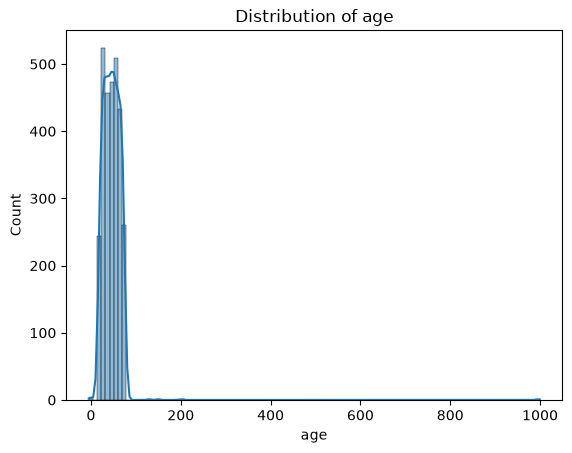

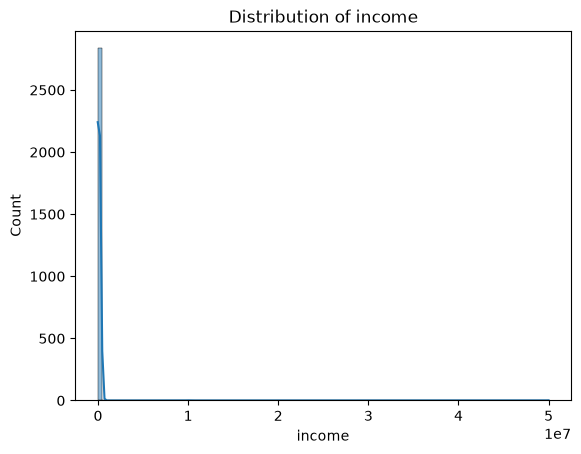

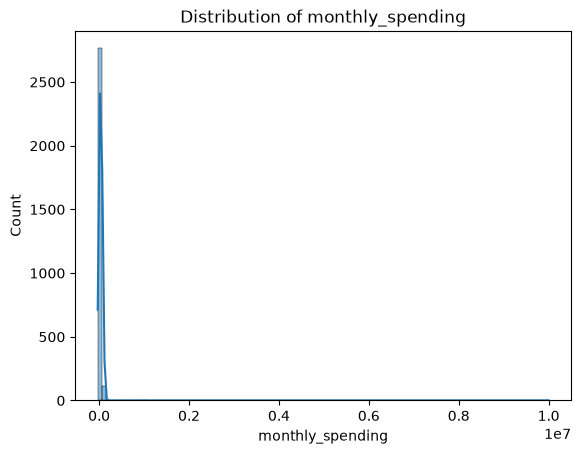

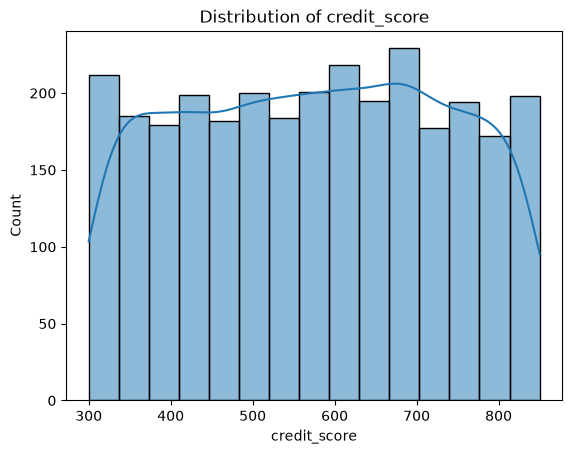

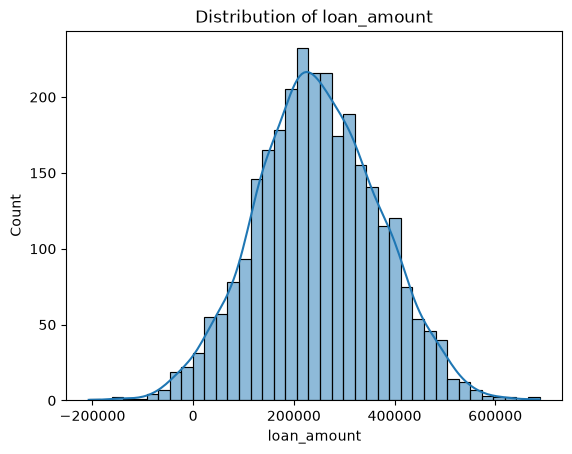

In [74]:
for col in num_col:
    if df[col].isnull().sum() > 0:
        sns.histplot(df[col], kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()

In [75]:
for col in num_col:
    if df[col].isnull().sum() > 0:
        print(f"\n{col}")
        print("Mean:", df[col].mean())
        print("Median:", df[col].median())


age
Mean: 46.23505154639175
Median: 46.0

income
Mean: 106427.18385754582
Median: 85566.14

monthly_spending
Mean: 39160.94313085734
Median: 34798.72

credit_score
Mean: 574.4615384615385
Median: 577.0

loan_amount
Mean: 247781.9033298611
Median: 243796.305


In [76]:
df["age"] = df["age"].fillna(df["age"].mean())

In [77]:
df["monthly_spending"] = df["monthly_spending"].fillna(
    df["monthly_spending"].median()
)

In [78]:
df["loan_amount"] = df["loan_amount"].fillna(
    df["loan_amount"].mean()
)

In [79]:
df["income"] = df["income"].fillna(df["income"].median())

In [80]:
df["credit_score"] = df["credit_score"].fillna(df["credit_score"].mean())

In [82]:
cat_cols = df.select_dtypes(include=["object", "string"]).columns

for col in cat_cols:
    print(col, ":", df[col].isnull().sum())

customer_id : 0
gender : 0
city : 75
education : 60
signup_date : 0
has_credit_card : 0
employment_type : 0


In [83]:
df["city"].value_counts(dropna=False)

city
islamabad     612
karachi       595
faisalabad    579
Lahore        579
rawalpindi    560
NaN            75
Name: count, dtype: int64

In [85]:
df["city"] = df["city"].fillna("Unknown")

In [84]:
df["education"].value_counts(dropna=False)

education
Bachelor        605
Master          597
Matric          586
PhD             586
Intermediate    566
NaN              60
Name: count, dtype: int64

In [88]:
df["education"] = df["education"].fillna("Unknown")

In [94]:
print("Null_values:",df.isnull().sum())
print("duplicates_values:",df.duplicated().sum())

Null_values: customer_id         0
age                 0
gender              0
city                0
income              0
education           0
experience_years    0
monthly_spending    0
credit_score        0
signup_date         0
has_credit_card     0
loan_amount         0
employment_type     0
defaulted           0
dtype: int64
duplicates_values: 0


### ✅ Missing values handle 
### ✅ Duplicate rows handle 
### ✅ Duplicate customer_id handle 
### ✅ income ko numeric mein convert 
### ✅ Categorical inconsistencies fix 
### ✅ Extra spaces/capitalization fix 
### ✅ Invalid dates handle 
### ✅ Invalid values/ranges check 
### ✅ Outliers check kiye
### ✅ Logical/business-rule problems check 